##### I. Setup

In [ ]:
!pip uninstall -y pyspark pyspark-connect dataproc-spark-connect

Found existing installation: pyspark 3.5.1
Uninstalling pyspark-3.5.1:
  Successfully uninstalled pyspark-3.5.1


In [ ]:
!pip install -q pyspark==3.5.1

In [ ]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-17-openjdk-amd64/bin"

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("DataCleaning") \
    .getOrCreate()

spark

In [ ]:
import os
from pyspark.sql import SparkSession, DataFrame
from google.colab import files
from pyspark.sql.functions import *
from pyspark.sql.types import TimestampType
from functools import reduce

In [ ]:
from google.colab import files
files= files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


##### II. Load data

In [ ]:
df = spark.read.csv("OnlineRetail.csv", header=True, inferSchema=True)
df.show(5)

+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|   InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|12/1/2010 8:26|     2.55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|12/1/2010 8:26|     2.75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|12/1/2010 8:26|     3.39|     17850|United Kingdom|
+---------+---------+--------------------+--------+--------------+---------+----------+--------------+
only showing top 5 rows



##### III. Data Profiling, Anomaly Detection, and Data Cleaning

###### 3.1 Check the number of columns and rows

In [ ]:
# Check the number of columns and rows
print("Number of columns: ", len(df.columns))
print("Number of rows: ", df.count())

Number of columns:  8
Number of rows:  541909


###### 3.2 Abnormal 1: Check and Correct data type

In [ ]:
# Check schema
df.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



In [ ]:
# Convert datatype of InvoiceDate to timestamp
df_cleaned = df.withColumn("InvoiceDate", to_timestamp("InvoiceDate", "M/d/yyyy H:mm"))

# Re-check schema
df_cleaned.printSchema()

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)



###### 3.3 Abnormal 2: Check and handle missing values

In [ ]:
# Check for missing values in original data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|       1454|       0|          0|        0|    135080|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



- `Description`: 1,454 --> remove since it is hard to guess the product description
- `CustomerID`: 135,080 --> might keep them, change `null` value into `Unknown`

In [ ]:
df_cleaned.filter(df.Description.isNull()).select("StockCode").distinct().count()

960

In [ ]:
missing_stockcodes = (
    df_cleaned
    .filter(col("Description").isNull())
    .select("StockCode")
    .distinct()
    .rdd.flatMap(lambda x: x)
    .collect()
)

In [ ]:
# Delete the null values in Description
df_cleaned = df_cleaned.filter(df_cleaned.Description.isNotNull())

# Change the value in CustomerID into "Unknown" for null values
df_cleaned = df_cleaned.withColumn("CustomerID", when(df_cleaned.CustomerID.isNull(), "Unknown").otherwise(df_cleaned.CustomerID))

In [ ]:
# Re-check for missing values in the cleaned data
missing_values = df_cleaned.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df_cleaned.columns
])
missing_values.show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|          0|       0|          0|        0|         0|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



###### 3.4 Abnormal 3: Check and handle duplicate rows

In [ ]:
# Check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  5268


In [ ]:
# Drop duplicate rows
df_cleaned = df_cleaned.dropDuplicates()

In [ ]:
# Re-check the number of duplicate rows
duplicate_count = df_cleaned.count() - df_cleaned.dropDuplicates().count()
print("Number of duplicate rows: ", duplicate_count)

Number of duplicate rows:  0


###### 3.5 Abnormal 4: Handle negative Quantity and UnitPrice

**Check the number of cancelled order:**

The InvoiceNo starts with C (has negative Quantity)

In [ ]:
cancel = df_cleaned.filter(col("InvoiceNo").startswith("C"))
print("Number of canceled orders: ", cancel.count())
cancel.show(5)

Number of canceled orders:  9251
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|  C536606|    20914|SET/5 RED RETROSP...|      -2|2010-12-02 09:10:00|     2.95|     14092|United Kingdom|
|  C537998|    22727|ALARM CLOCK BAKEL...|      -4|2010-12-09 11:42:00|     3.75|     17411|United Kingdom|
|  C538723|    22333|RETROSPOT PARTY B...|      -7|2010-12-14 11:12:00|     1.65|     12434|     Australia|
|  C538763|    22107|  PIZZA PLATE IN BOX|      -8|2010-12-14 11:33:00|     3.75|     17722|United Kingdom|
|  C539278|    22617|BAKING SET SPACEB...|      -6|2010-12-16 15:39:00|     4.95|     18269|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+-----------

**Check for invalid values in Quantity and UnitPrice:**
- Quantity < 0
- UnitPrice < 0

In [ ]:
# Quantity has negative value
negative_Quantity = df_cleaned.filter(col("Quantity") < 0).count()
print("Number of negative Quantity: ", negative_Quantity)
df_cleaned.filter(col("Quantity") < 0).select("InvoiceNo", "Quantity").show(5)

Number of negative Quantity:  9725
+---------+--------+
|InvoiceNo|Quantity|
+---------+--------+
|  C536606|      -2|
|  C537998|      -4|
|  C538723|      -7|
|  C538763|      -8|
|  C539278|      -6|
+---------+--------+
only showing top 5 rows



In [ ]:
# UnitPrice has negative value
negative_UnitPrice = df_cleaned.filter(col("UnitPrice") < 0).count()
print("Number of negative UnitPrice: ", negative_UnitPrice)
df_cleaned.filter(col("UnitPrice") < 0).select("InvoiceNo", "UnitPrice").show(5)

Number of negative UnitPrice:  2
+---------+---------+
|InvoiceNo|UnitPrice|
+---------+---------+
|  A563187|-11062.06|
|  A563186|-11062.06|
+---------+---------+



- We can see that cancelled orders also have the negative Quantity.
- The dataset contains 9,251 cancelled orders, while 9,725 orders have a negative quantity.
- Therefore, in the Data Cleaning section, when we remove orders with negative quantities, we also remove the cancelled orders at the same time.

**Remove abnormal Quantity and UnitPrice**

In [ ]:
# Filter out negative Quantity and UnitPrice
df_cleaned = df_cleaned.filter((col("Quantity") > 0) & (col("UnitPrice") > 0))

# Check negative Quantity and UnitPrice again
print("Negative Quantity count:", df_cleaned.filter(col("Quantity") < 0).count())
print("Negative UnitPrice count:", df_cleaned.filter(col("UnitPrice") < 0).count())

# Check number of cancelled orders again
cancel = df_cleaned.filter(col("InvoiceNo").startswith("C"))
print("Number of cancelled orders: ", cancel.count())

Negative Quantity count: 0
Negative UnitPrice count: 0
Number of cancelled orders:  0


###### 3.6 Abnormal 5: Identify abnormal `StockCode` - `Description` pairs that are not actual products

**Check abnormal StockCodes**

In [ ]:
excluded_stockcodes = ["POST", "DOT", "M", "C2", "BANK CHARGES","S", "B", "AMAZONFEE",
                       "gift_0001_10", "gift_0001_20","gift_0001_30","gift_0001_40","gift_0001_50"]

# Identify rows with exclued StockCode
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))

# Show distinct excluded StockCode - Description pairs
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+------------+----------------------------------+
|StockCode   |Description                       |
+------------+----------------------------------+
|POST        |POSTAGE                           |
|DOT         |DOTCOM POSTAGE                    |
|gift_0001_40|Dotcomgiftshop Gift Voucher �40.00|
|C2          |CARRIAGE                          |
|gift_0001_30|Dotcomgiftshop Gift Voucher �30.00|
|BANK CHARGES|Bank Charges                      |
|M           |Manual                            |
|AMAZONFEE   |AMAZON FEE                        |
|gift_0001_50|Dotcomgiftshop Gift Voucher �50.00|
|gift_0001_20|Dotcomgiftshop Gift Voucher �20.00|
|S           |SAMPLES                           |
|gift_0001_10|Dotcomgiftshop Gift Voucher �10.00|
|B           |Adjust bad debt                   |
+------------+----------------------------------+



**Handle abnormal `StockCode` and `Description` pairs that are not actual products**

In [ ]:
df_cleaned = df_cleaned.filter(~col("StockCode").isin(excluded_stockcodes))

In [ ]:
# Re-check the abnormal stock code
df_excluded = df_cleaned.filter(col("StockCode").isin(excluded_stockcodes))
df_excluded.select("StockCode", "Description").distinct().show(truncate=False)

+---------+-----------+
|StockCode|Description|
+---------+-----------+
+---------+-----------+



##### IV. Data Cleaning results

In [ ]:
# The number of rows before cleaning
rows_before_cleaning = df.count()
print(f"Number of rows before cleaning: {rows_before_cleaning}")

Number of rows before cleaning: 541909


In [ ]:
# Check the number of rows after cleaning
rows_after_cleaning = df_cleaned.count()
print(f"Number of rows after cleaning: {rows_after_cleaning}")

Number of rows after cleaning: 522541


##### V. Feature Engineering

###### 5.1 Create Recency, Frequency, and Monetary (RFM) features

Convert InvoiceDate to DateType

In [ ]:
from pyspark.sql.functions import col, to_date

# Convert InvoiceDate from string to DateType
df_fe = df_cleaned.withColumn("InvoiceDate", to_date(col("InvoiceDate"), "M/d/yyyy H:mm"))
df_fe.printSchema()
df_fe.show(5)

root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: date (nullable = true)
 |-- UnitPrice: double (nullable = true)
 |-- CustomerID: string (nullable = true)
 |-- Country: string (nullable = true)

+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-----------+---------+----------+--------------+
|   536415|    22951|60 CAKE CASES DOL...|       2| 2010-12-01|     0.55|     12838|United Kingdom|
|   536488|    22909|SET OF 20 VINTAGE...|       1| 2010-12-01|     0.85|     17897|United Kingdom|
|   536592|    22665|RECIPE BOX BLUE S...|       1| 2010-12-01|     5.91|   Unknown|United Kingdom|
|   536600|   84029G|KNITTED UNION FLA...|       6| 2010-12-02|  

In [ ]:
# Get the max date of the dataset
max_date = df_fe.agg(max("InvoiceDate")).collect()[0][0]
max_date

datetime.date(2011, 12, 9)

In [ ]:
# Calculate recency
recency_df = df_fe.groupBy("CustomerID").agg(
    datediff(lit(max_date), max("InvoiceDate")).alias("Recency")
)
recency_df.show()

+----------+-------+
|CustomerID|Recency|
+----------+-------+
|     16250|    261|
|     15574|    177|
|     15555|     12|
|     15271|      7|
|     17714|    320|
|     17686|      7|
|     13865|     58|
|     14157|     19|
|     13610|     12|
|     13772|     33|
|     13282|     18|
|     12394|     63|
|     16320|    172|
|     13192|     95|
|     17757|      1|
|     17551|    359|
|     13187|    337|
|     16549|     10|
|     12637|     67|
|     15052|    319|
+----------+-------+
only showing top 20 rows



In [ ]:
# Calculate frequency (number of transactions per customer)
frequency_df = df_fe.groupBy("CustomerID").agg(
    countDistinct("InvoiceNo").alias("Frequency")
)
frequency_df.show()

+----------+---------+
|CustomerID|Frequency|
+----------+---------+
|     15555|       16|
|     15574|        4|
|     14157|        2|
|     17686|        7|
|     13610|        7|
|     13865|        4|
|     16250|        2|
|     17714|        1|
|     13282|        3|
|     15271|       15|
|     16320|        2|
|     12394|        2|
|     13192|        2|
|     15634|        1|
|     14204|        1|
|     17427|        1|
|     18130|        3|
|     15269|        1|
|     16504|        1|
|     12847|        1|
+----------+---------+
only showing top 20 rows



In [ ]:
# Calculate Monetary (Total money spent by customer)
monetary_df = df_fe.withColumn("TotalPrice", col("Quantity") * col("UnitPrice")) \
    .groupBy("CustomerID") \
    .agg(round(sum("TotalPrice"), 3).alias("Monetary"))
monetary_df.show()

+----------+--------+
|CustomerID|Monetary|
+----------+--------+
|     13610| 1082.33|
|     15555| 4791.87|
|     15271| 2493.34|
|     15574|  675.64|
|     13282| 1132.14|
|     14157|  424.89|
|     16250|  389.44|
|     12394| 1080.48|
|     17686| 5739.46|
|     16320| 1038.46|
|     13865|  501.56|
|     13772| 1122.63|
|     17714|   153.0|
|     13192|  911.94|
|     18130| 1059.39|
|     16504|  465.88|
|     17506|   302.2|
|     12847|  843.64|
|     14887|  1862.0|
|     14204|  150.61|
+----------+--------+
only showing top 20 rows



In [ ]:
# Join all RFM features
dfs = [recency_df, frequency_df, monetary_df]
rfm_df = reduce(lambda df1, df2: df1.join(df2, "CustomerID"), dfs)
rfm_df.show()

+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
|     15555|     12|       16| 4791.87|
|     15574|    177|        4|  675.64|
|     14157|     19|        2|  424.89|
|     17686|      7|        7| 5739.46|
|     13610|     12|        7| 1082.33|
|     13865|     58|        4|  501.56|
|     16250|    261|        2|  389.44|
|     17714|    320|        1|   153.0|
|     13282|     18|        3| 1132.14|
|     15271|      7|       15| 2493.34|
|     16320|    172|        2| 1038.46|
|     12394|     63|        2| 1080.48|
|     13192|     95|        2|  911.94|
|     15634|     17|        1|  243.55|
|     14204|      2|        1|  150.61|
|     17427|     71|        1|   100.8|
|     18130|     15|        3| 1059.39|
|     15269|     23|        1|   408.8|
|     16504|     25|        1|  465.88|
|     12847|     22|        1|  843.64|
+----------+-------+---------+--------+
only showing top 20 rows



In [ ]:
from pyspark.sql.functions import mean

rfm_df.select(
    mean("Recency").alias("Mean_Recency"),
    mean("Frequency").alias("Mean_Frequency"),
    mean("Monetary").alias("Mean_Monetary")
).show()


+-----------------+-----------------+-----------------+
|     Mean_Recency|   Mean_Frequency|    Mean_Monetary|
+-----------------+-----------------+-----------------+
|92.20530565167243|4.561245674740484|2363.834342099192|
+-----------------+-----------------+-----------------+



In [ ]:
# Define thresholds based on the mean values
recency_threshold = 95
frequency_threshold = 7

# Create a new column 'Churn' based on the thresholds
rfm_df = rfm_df.withColumn(
    "Churn",
    when((col("Recency") > recency_threshold) & (col("Frequency") <= frequency_threshold), 1).otherwise(0)
)

# Show the resulting DataFrame with Churn column
rfm_df.select("CustomerID", "Recency", "Frequency", "Monetary", "Churn").show(50)

+----------+-------+---------+--------+-----+
|CustomerID|Recency|Frequency|Monetary|Churn|
+----------+-------+---------+--------+-----+
|     15555|     12|       16| 4791.87|    0|
|     15574|    177|        4|  675.64|    1|
|     14157|     19|        2|  424.89|    0|
|     17686|      7|        7| 5739.46|    0|
|     13610|     12|        7| 1082.33|    0|
|     13865|     58|        4|  501.56|    0|
|     16250|    261|        2|  389.44|    1|
|     17714|    320|        1|   153.0|    1|
|     13282|     18|        3| 1132.14|    0|
|     15271|      7|       15| 2493.34|    0|
|     16320|    172|        2| 1038.46|    1|
|     12394|     63|        2| 1080.48|    0|
|     13192|     95|        2|  911.94|    0|
|     15634|     17|        1|  243.55|    0|
|     14204|      2|        1|  150.61|    0|
|     17427|     71|        1|   100.8|    0|
|     18130|     15|        3| 1059.39|    0|
|     15269|     23|        1|   408.8|    0|
|     16504|     25|        1|  46

In [ ]:
# join data
final_df= df_fe.join(rfm_df,on= 'CustomerID', how= 'left')
final_df.show()

+----------+---------+---------+--------------------+--------+-----------+---------+--------------+-------+---------+--------+-----+
|CustomerID|InvoiceNo|StockCode|         Description|Quantity|InvoiceDate|UnitPrice|       Country|Recency|Frequency|Monetary|Churn|
+----------+---------+---------+--------------------+--------+-----------+---------+--------------+-------+---------+--------+-----+
|     12427|   536861|    22301|COFFEE MUG CAT + ...|       6| 2010-12-03|     2.55|       Germany|     21|        3|   699.8|    0|
|     12433|   536532|    22534|MAGIC DRAWING SLA...|      24| 2010-12-01|     0.42|        Norway|      0|        7|13375.87|    0|
|     12838|   536415|    22951|60 CAKE CASES DOL...|       2| 2010-12-01|     0.55|United Kingdom|     33|        2|  671.95|    0|
|     12915|   536707|   85132C|CHARLIE AND LOLA ...|       1| 2010-12-02|     9.95|United Kingdom|    148|        2|  363.65|    1|
|     13013|   536947|   84534B|FAIRY CAKE NOTEBO...|      24| 2010-1

### Customer Churn & Value Analysis: A 3Ps-G Framework Approach
- This analysis aims to understand customer churn behavior and uncover opportunities to drive long-term growth by applying the 3Ps-G Framework — a strategic lens that evaluates customer dynamics through four key dimensions: Place, People, Product, and Growth.
- The 3P-G framework is not academic but has emerged from practical growth operating systems used by growth-stage startups and tech companies (inspired by frameworks like AARRR or McKinsey’s 7S). It gained popularity among product managers, data analysts, and growth teams as a way to structure root cause analysis around user problems or retention issues

### Overall RFM by churn
- This is also conducted through the 3Ps-G frameworks:

In [ ]:
final_df.groupBy("Churn") \
    .agg(
        avg("Recency").alias("Avg_Recency"),
        avg("Frequency").alias("Avg_Frequency"),
        avg("Monetary").alias("Avg_Monetary"),
        countDistinct("CustomerID").alias("Num_Customers")
    ).show()

+-----+------------------+-----------------+-----------------+-------------+
|Churn|       Avg_Recency|    Avg_Frequency|     Avg_Monetary|Num_Customers|
+-----+------------------+-----------------+-----------------+-------------+
|    1| 196.9810371336719|2.335018403764618|963.0007898942375|         1376|
|    0|15.614847325458962|390.5494406972259|422701.3430559438|         2959|
+-----+------------------+-----------------+-----------------+-------------+



### Customer Behavior Breakdown By RFM metrics
- Based on the data, churned customers account for nearly one-third of the total customer base (1,376 out of 4,335). Their behavior suggests a pattern of one-time purchases, as indicated by significantly higher recency and very low frequency and monetary values. Active users, on the other hand, outperformed churn customers in engagement time, number of purchases, and the revenue they brought in.

- Avg_Recency: ~16 days (vs. ~197 days for churned)

- Avg_Frequency: ~390 purchases (vs. ~2.3)

- Avg_Monetary: ~$422,701 (vs. ~$963)

These metrics showed that active customers spend approximately 43,800% more on average than churned ones — highlighting the urgent need of rententention strategies.

### Are there certain products/StockCodes more common in orders with high Recency (long since last purchase)?

In [ ]:
from pyspark.sql.functions import col, percentile_approx, first
recency_threshold = final_df.select(
    percentile_approx("Recency", 0.75).alias("recency_75th")
).collect()[0]["recency_75th"]
high_recency_customers = final_df.filter(col("Recency") >= recency_threshold) \
    .select(['CustomerID'])
high_recency_txns = high_recency_customers.join(final_df, on="CustomerID", how="inner")
high_recency_products = high_recency_txns.groupBy("StockCode") \
    .count() \
    .orderBy(col("count").desc())
product_desc = final_df.select("StockCode", "Description") \
    .dropna() \
    .dropDuplicates(["StockCode"])

high_recency_products_with_desc = high_recency_products.join(product_desc, on="StockCode", how="left")
high_recency_products_with_desc.select("StockCode", "Description", "count") \
    .show(20, truncate=False)


+---------+-----------------------------------+-----+
|StockCode|Description                        |count|
+---------+-----------------------------------+-----+
|22728    |ALARM CLOCK BAKELIKE PINK          |39894|
|21452    |TOADSTOOL MONEY BOX                |6585 |
|21889    |WOODEN BOX OF DOMINOES             |19458|
|21259    |VICTORIAN SEWING BOX SMALL         |7681 |
|21249    |WOODLAND  HEIGHT CHART STICKERS    |2691 |
|23318    |BOX OF 6 MINI VINTAGE CRACKERS     |8924 |
|22121    |NOEL WOODEN BLOCK LETTERS          |4924 |
|22254    |FELT TOADSTOOL LARGE               |1837 |
|22596    |CHRISTMAS STAR WISH LIST CHALKBOARD|5160 |
|21894    |POTTING SHED SEED ENVELOPES        |2998 |
|20868    |SILVER FABRIC MIRROR               |1043 |
|21331    |MOROCCAN BEATEN METAL DISH LARGE   |368  |
|21248    |DOOR HANGER  MUM + DADS ROOM       |3380 |
|90197B   |BLACK GLASS BRACELET W HEART CHARMS|149  |
|90143    |SILVER BRACELET W PASTEL FLOWER    |1005 |
|90210B   |CLEAR ACRYLIC FAC

### Summary Of Insights Of Long-Time Customers:
- Old-time buyers are showing strong interest in aesthetically appealing,  and seasonal home decor and gift items with a vintage vibe.
- Products like ALARM CLOCK BAKELIKE PINK, RED RETROSPOT SMALL MILK JUG, and BOX OF 6 MINI VINTAGE CRACKERS suggest a consistent preference for retro-style or vintage-themed items.
- WOODLAND HEIGHT CHART STICKERS, CHRISTMAS STAR WISH LIST CHALKBOARD, and FELT TOADSTOOL LARGE indicate that buyers are actively purchasing home decor, likely for seasonal holiday such as Christmas.
- TOADSTOOL MONEY BOX, OFFICE MUG WARMER CHOC+BLUE, and DOOR HANGER MUM + DADS ROOM suggests a high interest from office workers for a personalized, me-style everyday items such as mug



### Are there any popular products in customers with low recency (new customers):

In [ ]:
from pyspark.sql.functions import col, percentile_approx, row_number
from pyspark.sql.window import Window

recency_threshold = final_df.select(
    percentile_approx("Recency", 0.25).alias("recency_25th")
).collect()[0]["recency_25th"]

low_recency_customers = final_df.filter(col("Recency") <= recency_threshold) \
    .select(['CustomerID'])

low_recency_txns = low_recency_customers.join(final_df, on="CustomerID", how="inner")

low_recency_products = low_recency_txns.groupBy("StockCode") \
    .count() \
    .orderBy(col("count").desc())

windowSpec = Window.partitionBy("StockCode").orderBy("Description")

product_desc = final_df.select("StockCode", "Description") \
    .dropna() \
    .withColumn("row_num", row_number().over(windowSpec)) \
    .filter(col("row_num") == 1) \
    .drop("row_num")

low_recency_products_with_desc = low_recency_products.join(product_desc, on="StockCode", how="left")

low_recency_products_with_desc.select("StockCode", "Description", "count") \
    .show(20, truncate=False)


+---------+-----------------------------------+--------+
|StockCode|Description                        |count   |
+---------+-----------------------------------+--------+
|21248    |DOOR HANGER  MUM + DADS ROOM       |1840272 |
|22728    |ALARM CLOCK BAKELIKE PINK          |22613414|
|21249    |WOODLAND  HEIGHT CHART STICKERS    |5256046 |
|22254    |FELT TOADSTOOL LARGE               |2628184 |
|22121    |NOEL WOODEN BLOCK LETTERS          |2517174 |
|22596    |CHRISTMAS STAR WISH LIST CHALKBOARD|3702357 |
|23459    |DOLLY CABINET 2 DRAWERS            |222     |
|21889    |WOODEN BOX OF DOMINOES             |18149398|
|23318    |BOX OF 6 MINI VINTAGE CRACKERS     |6200251 |
|90197B   |BLACK GLASS BRACELET W HEART CHARMS|3416088 |
|21894    |POTTING SHED SEED ENVELOPES        |7756289 |
|21452    |TOADSTOOL MONEY BOX                |6713979 |
|90143    |SILVER BRACELET W PASTEL FLOWER    |1576656 |
|21259    |VICTORIAN SEWING BOX SMALL         |6309318 |
|20868    |SILVER FABRIC MIRROR

### Are churn rates higher in certain countries?

In [ ]:
from pyspark.sql.functions import col, countDistinct, when
churn_by_country = final_df.groupBy("Country").agg(
    countDistinct(when(col("Churn") == 1, col("CustomerID"))).alias("Churned_Customers"),
    countDistinct(when(col("Churn") == 0, col("CustomerID"))).alias("Active_Customers")
)

churn_by_country = churn_by_country.withColumn(
    "Churn_Rate",
    col("Churned_Customers") / (col("Churned_Customers") + col("Active_Customers"))
)


In [ ]:
churn_pd = churn_by_country.orderBy(col("Churn_Rate").desc()).toPandas()

In [ ]:
print(churn_pd)

                 Country  Churned_Customers  Active_Customers  Churn_Rate
0     European Community                  1                 0    1.000000
1              Lithuania                  1                 0    1.000000
2           Saudi Arabia                  1                 0    1.000000
3   United Arab Emirates                  2                 0    1.000000
4                 Canada                  4                 0    1.000000
5                 Brazil                  1                 0    1.000000
6                Lebanon                  1                 0    1.000000
7            Unspecified                  4                 1    0.800000
8                 Greece                  3                 1    0.750000
9                Bahrain                  2                 1    0.666667
10       Channel Islands                  5                 4    0.555556
11                 Malta                  1                 1    0.500000
12                Israel              

/tmp/ipykernel_15149/3316076459.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_pd, x="Churn_Rate", y="Country", palette="Reds_r")


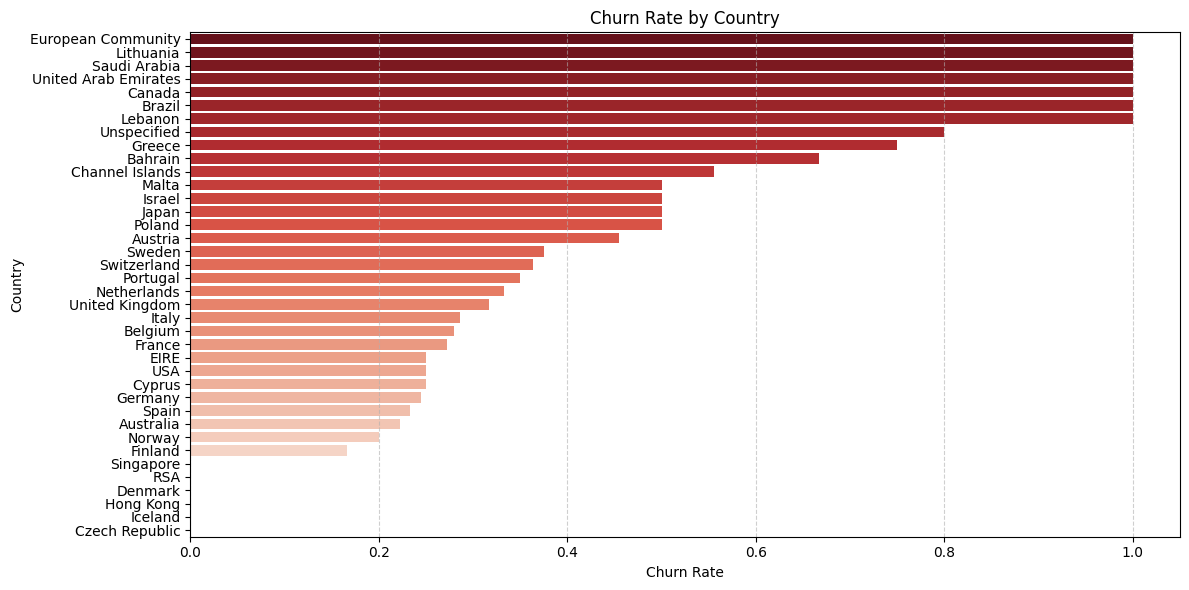

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=churn_pd, x="Churn_Rate", y="Country", palette="Reds_r")
plt.title("Churn Rate by Country")
plt.xlabel("Churn Rate")
plt.ylabel("Country")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Churn Rate Breakdown By Countries
- United Kingdom — Largest Market: Customers: ~3,900 total (2706 active + 1211 churned) -> Main revenue driver, but churn rate is nearly 1/3 of total customers
- Countries like Singapore, Saudi Arabia, Lithuania have NaN churn rates due to missing active or churned customers
- Greece, Canada, Bahrain: Very high churn, but small customer base (1–3 active customers) — is this a outlier or data entry problem?
- Unspecified-> subscious entry-> maybe a data entry issue
- Austria: mid-size market, but notable churn rate
- Channel Islands: small size market, but notably high churn rate
- Finland, Norway, Germany, Spain: low churn rate, and mid-size market

### 3. People

### Which churned customers had high past value? Can they be targeted for reactivation?

In [ ]:
quantiles = final_df.approxQuantile("Monetary", [0.75], 0.01)
high_value_threshold = quantiles[0]
high_value_churned = final_df.filter(
    (col("Churn") == 1) & (col("Monetary") >= high_value_threshold)
)
high_value_churned.select("CustomerID", "Recency", "Frequency", "Monetary").show(10)


+----------+-------+---------+--------+
|CustomerID|Recency|Frequency|Monetary|
+----------+-------+---------+--------+
+----------+-------+---------+--------+



 - No churned customers have past high values -> 1. they almost leave after 1 and second purchase maybe because of customer service or product-related problems.


### Which countries contribute the most revenue?

In [ ]:
from pyspark.sql.functions import col, sum as _sum

# Compute revenue per country
revenue_by_country_df = final_df.withColumn("Revenue", col("Quantity") * col("UnitPrice")) \
    .groupBy("Country") \
    .agg(_sum("Revenue").alias("Total_Revenue")) \
    .orderBy(col("Total_Revenue").desc())
revenue_pd = revenue_by_country_df.toPandas()


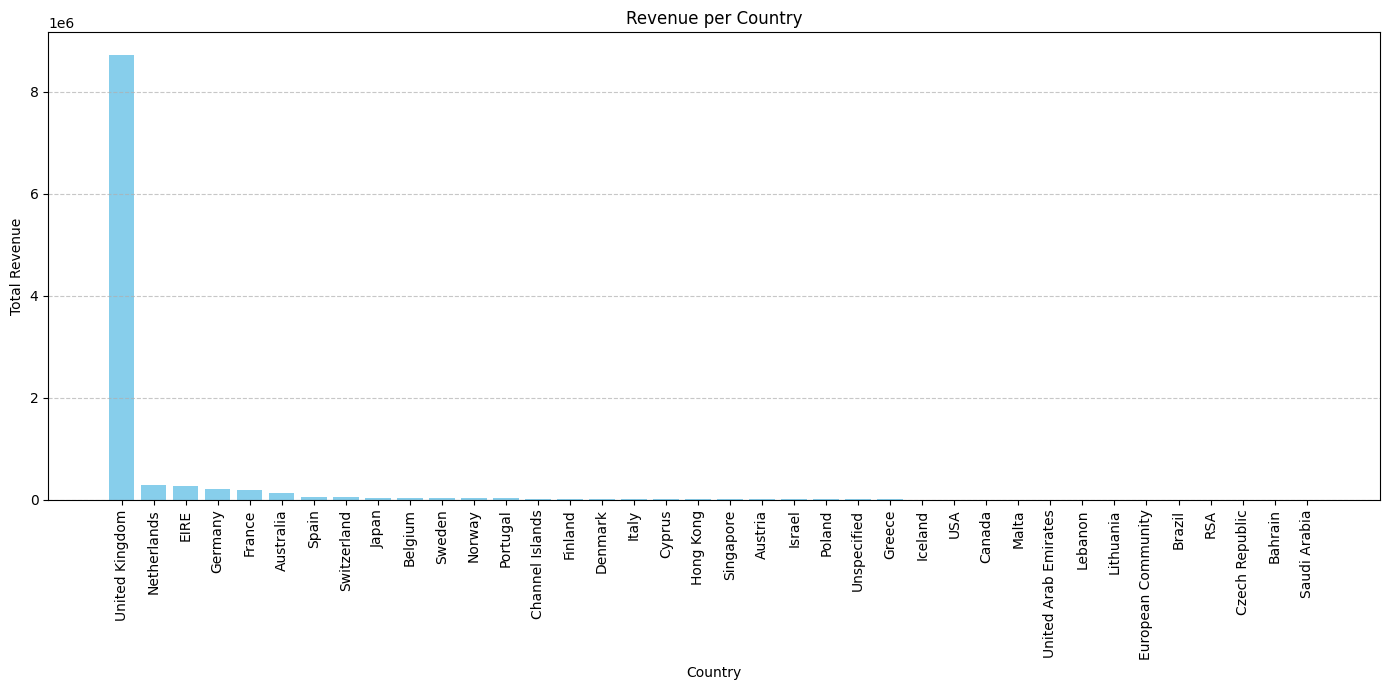

In [ ]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(14, 7))
plt.bar(revenue_pd["Country"], revenue_pd["Total_Revenue"], color='skyblue')
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.title("Revenue per Country")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

- The United Kingdom outperforming other countries in revenue-> suggesting a strong customer base in this country
- The revenue from the Netherlands, EIRE (Ireland), Germany, and France—while next in line—is negligible in comparison to the UK.
- Most top-performing countries are concentrated in the Europe

### 2. The YOY growth in revenue of each countries

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_with_year = final_df.withColumn("Year", F.year("InvoiceDate"))

# revenue per year
revenue_per_year = df_with_year.groupBy("Country", "Year") \
    .agg(F.sum("Monetary").alias("YearlyRevenue"))

# window spec
window_spec = Window.partitionBy("Country").orderBy("Year")

# yoy growth
revenue_growth = revenue_per_year.withColumn(
    "PreviousRevenue", F.lag("YearlyRevenue").over(window_spec)
).withColumn(
    "YoY_Growth",
    F.round(
        (F.col("YearlyRevenue") - F.col("PreviousRevenue"))
        / F.col("PreviousRevenue") * 100, 2
    )
).orderBy("Country", "Year")

revenue_growth.show()

+------------------+----+--------------------+-------------------+----------+
|           Country|Year|       YearlyRevenue|    PreviousRevenue|YoY_Growth|
+------------------+----+--------------------+-------------------+----------+
|         Australia|2010|           148459.05|               NULL|      NULL|
|         Australia|2011|  9.02980876000006E7|          148459.05|  60723.57|
|           Austria|2010|  23953.579999999998|               NULL|      NULL|
|           Austria|2011|   599526.1699999985| 23953.579999999998|   2402.87|
|           Bahrain|2010|          1509994.23|               NULL|      NULL|
|           Bahrain|2011|   6328.199999999999|         1509994.23|    -99.58|
|           Belgium|2010|           193200.08|               NULL|      NULL|
|           Belgium|2011|   4726419.039999983|          193200.08|   2346.39|
|            Brazil|2011|   36595.19999999998|               NULL|      NULL|
|            Canada|2011|  322336.83999999985|               NUL

### YoY (Year Over Year Growth In Revenue) Walk Through:
- Channel Islands: +72,425% YoY (leading growing market)-> target them with new customer campaign to turn them into loyal customers
- Australia: +60,724% YoY (148K -> 90M) -> massive growing market
- Bahrain: -99.58% YoY -> almost frozen market
- Countries like Brazil, Canada, Czech Republic, European Community only start buying from us in 2011
- Austria: +2,403% YoY, Denmark: +1,406% YoY and Ireland (EIRE): +1,723% YoY. Grow slightly better than next year-> customer feedback analysis needed to discover how we can target these markets better

### Sales Trend Of Top 3 Countries In Revenue


In [ ]:
from pyspark.sql.functions import col, sum as _sum

# Compute total revenue per country
top_countries_df = final_df.withColumn("Revenue", col("Quantity") * col("UnitPrice")) \
    .groupBy("Country") \
    .agg(_sum("Revenue").alias("Total_Revenue")) \
    .orderBy(col("Total_Revenue").desc()) \
    .limit(3)

top_countries = [row["Country"] for row in top_countries_df.collect()]
print("Top 3 Countries by Revenue:", top_countries)


Top 3 Countries by Revenue: ['United Kingdom', 'Netherlands', 'EIRE']


In [ ]:
from pyspark.sql.functions import month, year

# Filter only top 3 countries
filtered_df = final_df.filter(col("Country").isin(top_countries))

# Compute monthly revenue
monthly_revenue_trend = filtered_df.withColumn("Revenue", col("Quantity") * col("UnitPrice")) \
    .withColumn("Year", year("InvoiceDate")) \
    .withColumn("Month", month("InvoiceDate")) \
    .groupBy("Year", "Month", "Country") \
    .agg(_sum("Revenue").alias("Total_Revenue")) \
    .orderBy("Year", "Month", "Country")


In [ ]:
# Convert to Pandas
monthly_pd = monthly_revenue_trend.toPandas()
monthly_pd["YearMonth"] = monthly_pd["Year"].astype(str) + "-" + monthly_pd["Month"].astype(str).str.zfill(2)

# Sort by time
monthly_pd = monthly_pd.sort_values(["Year", "Month"])


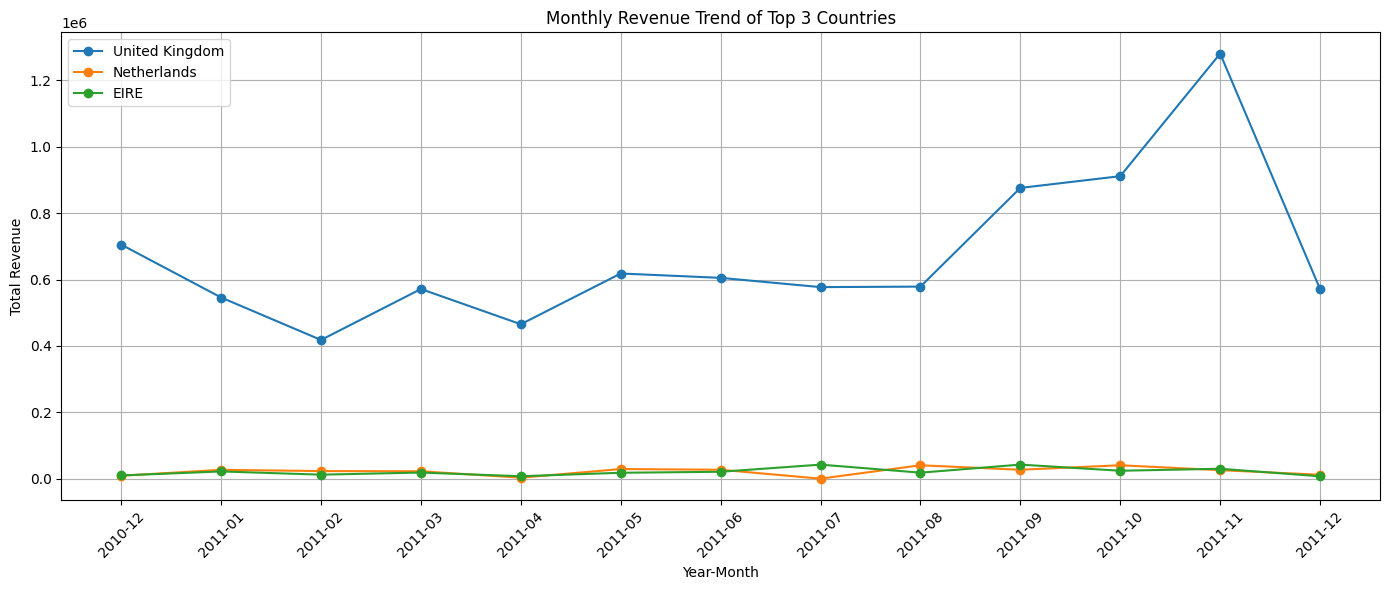

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
for country in top_countries:
    country_data = monthly_pd[monthly_pd["Country"] == country]
    plt.plot(country_data["YearMonth"], country_data["Total_Revenue"], label=country, marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend of Top 3 Countries")
plt.xlabel("Year-Month")
plt.ylabel("Total Revenue")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


- The UK is the top 1 performer in revenue, and revenue of this country suddenly spike in 11/2011 and significantly decrease in the next month-> a season purchasing behavior, strongly linked to
- Other countries in top 3 revenue often have a plateu-like purchasing pattern, with a slightly increase in mid-year period (7-8/2011)

### What are the top 10 best-selling products by quantity?

In [ ]:
from pyspark.sql.functions import sum as _sum
top_products = final_df.groupBy("Description") \
    .agg(_sum("Quantity").alias("TotalQuantity")) \
    .orderBy("TotalQuantity", ascending=False)
top_products.show(10, truncate=False)


+----------------------------------+-------------+
|Description                       |TotalQuantity|
+----------------------------------+-------------+
|PAPER CRAFT , LITTLE BIRDIE       |80995        |
|MEDIUM CERAMIC TOP STORAGE JAR    |78033        |
|WORLD WAR 2 GLIDERS ASSTD DESIGNS |54951        |
|JUMBO BAG RED RETROSPOT           |48371        |
|WHITE HANGING HEART T-LIGHT HOLDER|37872        |
|POPCORN HOLDER                    |36749        |
|PACK OF 72 RETROSPOT CAKE CASES   |36396        |
|ASSORTED COLOUR BIRD ORNAMENT     |36362        |
|RABBIT NIGHT LIGHT                |30739        |
|MINI PAINT SET VINTAGE            |26633        |
+----------------------------------+-------------+
only showing top 10 rows



- The top-selling product is "PAPER CRAFT , LITTLE BIRDIE" with over 80,000 units sold, indicating a strong customer interest in affordable, decorative, and possibly DIY-themed items
- Other best selling rpoducts such as ceramic jar, or asstd designs, or other decorations-> customers have preference for unique, niche decorative products.

### Which products churned customers mostly buy and when they buy them?

In [ ]:
from pyspark.sql.functions import col, sum as _sum, desc, month, year, to_date
churned_df = final_df.filter(col("Churn") == 1)

top_products = churned_df.groupBy("StockCode", "Description") \
    .agg(_sum("Quantity").alias("TotalQuantity")) \
    .orderBy(desc("TotalQuantity")) \
    .limit(3)
top_products.show(truncate=False)

+---------+----------------------------------+-------------+
|StockCode|Description                       |TotalQuantity|
+---------+----------------------------------+-------------+
|23166    |MEDIUM CERAMIC TOP STORAGE JAR    |74442        |
|85123A   |WHITE HANGING HEART T-LIGHT HOLDER|7180         |
|21212    |PACK OF 72 RETROSPOT CAKE CASES   |7070         |
+---------+----------------------------------+-------------+



- Worth-noticing is that, Stock Code: 23166 appears both in best-selling lists, and top purchasing for churn customers
- Other products are also fragile, and decorative items-> investigate the quality of products through customer feedbacks

### 5. Growth

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

product_df = final_df.withColumn("Year", F.year("InvoiceDate"))

# Calculate total revenue per product per year
product_year_revenue = product_df.groupBy("StockCode", "Description", "Year") \
    .agg(F.sum(F.col("Quantity") * F.col("UnitPrice")).alias("YearlyRevenue"))
window_spec = Window.partitionBy("StockCode").orderBy("Year")

# Get previous year's revenue to calculate YoY growth
product_year_revenue = product_year_revenue.withColumn(
    "PreviousYearRevenue", F.lag("YearlyRevenue").over(window_spec))

# Calculate YoY growth %
product_year_revenue = product_year_revenue.withColumn(
    "YoY_Growth",
    (F.col("YearlyRevenue") - F.col("PreviousYearRevenue")) / F.col("PreviousYearRevenue") * 100)
product_year_revenue_filtered = product_year_revenue.filter(F.col("PreviousYearRevenue").isNotNull())
top_growth_products = product_year_revenue_filtered.orderBy(F.desc("YoY_Growth"))
top_growth_products.show(20, False)


+---------+----------------------------------+----+------------------+-------------------+------------------+
|StockCode|Description                       |Year|YearlyRevenue     |PreviousYearRevenue|YoY_Growth        |
+---------+----------------------------------+----+------------------+-------------------+------------------+
|22148    |EASTER CRAFT 4 CHICKS             |2011|3913.2400000000057|4.21               |92851.06888361058 |
|75049L   |LARGE CIRCULAR MIRROR MOBILE      |2011|6805.450000000001 |7.529999999999999  |90277.82204515274 |
|22698    |PINK REGENCY TEACUP AND SAUCER    |2011|17424.89999999995 |20.66              |84241.23910938989 |
|21090    |SET/6 COLLAGE PAPER PLATES        |2011|1272.4899999999993|1.7                |74752.35294117643 |
|22597    |MUSICAL ZINC HEART DECORATION     |2011|1179.59           |1.63               |72267.48466257668 |
|22952    |60 CAKE CASES VINTAGE CHRISTMAS   |2011|8616.029999999988 |13.200000000000001 |65172.95454545444 |
|47422    

- It is noticeble that specialize products for holidy events such as Christmas, are growing very fast. Our customers are also shifting their interest towards souvernirs, gifts, or special occassion items such as wedding day card.

### Market Basket Analysis

In [ ]:
from pyspark.sql import functions as F

# loại bỏ đơn hủy + quantity <= 0 để AOV không bị méo
df_clean = final_df.filter(
    (~F.col("InvoiceNo").startswith("C")) &
    (F.col("Quantity") > 0)
)

# giá trị mỗi dòng (nếu Monetary đã là line total thì có thể dùng luôn)
df_clean = df_clean.withColumn(
    "line_revenue",
    F.col("Quantity") * F.col("UnitPrice")
)

# gom về order-level
order_df = df_clean.groupBy("CustomerID", "InvoiceNo", "Churn") \
    .agg(F.sum("line_revenue").alias("order_value"))

In [ ]:
aov_all = order_df.agg(
    (F.sum("order_value") / F.countDistinct("InvoiceNo")).alias("AOV_all")
)

aov_all.show()

+-----------------+
|          AOV_all|
+-----------------+
|518.2431534415637|
+-----------------+



In [ ]:
aov_by_churn = order_df.groupBy("Churn") \
    .agg(
        (F.sum("order_value") / F.countDistinct("InvoiceNo")).alias("AOV")
    )

aov_by_churn.show()

+-----+------------------+
|Churn|               AOV|
+-----+------------------+
|    1|387.43439423903715|
|    0| 535.6823220037851|
+-----+------------------+



In [ ]:
customer_aov = order_df.groupBy("CustomerID", "Churn") \
    .agg(F.avg("order_value").alias("customer_avg_order_value"))

customer_aov.groupBy("Churn").agg(
    F.avg("customer_avg_order_value").alias("avg_customer_AOV")
).show()

+-----+------------------+
|Churn|  avg_customer_AOV|
+-----+------------------+
|    1| 405.0212878080012|
|    0|420.57952791810146|
+-----+------------------+



In [ ]:
from pyspark.sql import functions as F

# Nếu chưa cast time
df = final_df

# Loại bỏ đơn hủy (Invoice bắt đầu bằng 'C') và quantity <= 0
df_clean = df.filter(
    (~F.col("InvoiceNo").startswith("C")) &
    (F.col("Quantity") > 0)
)

# Tạo basket
basket_df = df_clean.groupBy("InvoiceNo") \
    .agg(F.collect_set("StockCode").alias("items"))

In [ ]:
from pyspark.ml.fpm import FPGrowth

fp = FPGrowth(
    itemsCol="items",
    minSupport=0.02,     # thử 0.005–0.02 tùy độ dày dữ liệu
    minConfidence=0.3    # rule đủ “chắc”
)

model = fp.fit(basket_df)

In [ ]:
# đếm tần suất item
item_freq = df_clean.groupBy("StockCode").count()

# giữ item phổ biến (ví dụ >= 50 lần)
popular_items = item_freq.filter("count >= 50").select("StockCode")

df_filtered = df_clean.join(popular_items, "StockCode")

basket_df = df_filtered.groupBy("InvoiceNo") \
    .agg(F.collect_set("StockCode").alias("items"))

In [ ]:
basket_df = basket_df.repartition(200)
basket_df.cache()
basket_df.count()  # trigger

19584

In [ ]:
basket_sample = basket_df.sample(0.3, seed=42)

model = fp.fit(basket_sample)
model.freqItemsets.show(20, truncate=False)

+---------------+----+
|items          |freq|
+---------------+----+
|[22568]        |142 |
|[85123A]       |672 |
|[85099B]       |619 |
|[22951]        |142 |
|[22423]        |565 |
|[22804]        |142 |
|[47566]        |508 |
|[21154]        |142 |
|[20725]        |457 |
|[20725, 85099B]|170 |
|[22661]        |141 |
|[84879]        |450 |
|[85150]        |141 |
|[22197]        |415 |
|[22197, 85099B]|122 |
|[21231]        |141 |
|[22383]        |410 |
|[22383, 20725] |197 |
|[22988]        |141 |
|[21212]        |407 |
+---------------+----+
only showing top 20 rows



In [ ]:
model.freqItemsets \
    .orderBy(F.desc("freq")) \
    .limit(50) \
    .show(truncate=False)

+--------+----+
|items   |freq|
+--------+----+
|[85123A]|672 |
|[85099B]|619 |
|[22423] |565 |
|[47566] |508 |
|[20725] |457 |
|[84879] |450 |
|[22197] |415 |
|[22383] |410 |
|[21212] |407 |
|[22720] |390 |
|[22457] |376 |
|[21931] |372 |
|[22469] |369 |
|[22411] |368 |
|[20727] |368 |
|[22960] |363 |
|[22961] |360 |
|[23203] |357 |
|[22386] |357 |
|[22382] |354 |
+--------+----+
only showing top 20 rows



In [69]:
item_lookup = df_clean.select("StockCode", "Description").dropDuplicates()

In [70]:
decoded_freq = model.freqItemsets

decoded_freq = decoded_freq \
    .withColumn("item1", F.explode("items")) \
    .join(item_lookup.withColumnRenamed("StockCode","item1"), "item1") \
    .groupBy("items") \
    .agg(F.collect_list("Description").alias("descriptions"),
         F.first("freq").alias("freq"))

In [71]:
decoded_freq = model.freqItemsets

decoded_freq = decoded_freq \
    .withColumn("item1", F.explode("items")) \
    .join(item_lookup.withColumnRenamed("StockCode","item1"), "item1") \
    .groupBy("items") \
    .agg(F.collect_list("Description").alias("descriptions"),
         F.first("freq").alias("freq"))

In [72]:
rules = model.associationRules
rules.orderBy(F.desc("lift")).show(50, truncate=False)

+---------------+----------+-------------------+------------------+--------------------+
|antecedent     |consequent|confidence         |lift              |support             |
+---------------+----------+-------------------+------------------+--------------------+
|[22577]        |[22578]   |0.7158469945355191 |26.53969385330754 |0.02194672474451332 |
|[22578]        |[22577]   |0.8136645962732919 |26.539693853307536|0.02194672474451332 |
|[22697, 22699] |[22698]   |0.7098214285714286 |19.17160229476406 |0.026637627743340594|
|[22698, 22699] |[22697]   |0.9137931034482759 |18.808382877526753|0.026637627743340594|
|[22697]        |[22698]   |0.6241379310344828 |16.857372444999218|0.030323337242419167|
|[22698]        |[22697]   |0.8190045248868778 |16.857372444999218|0.030323337242419167|
|[22698, 22697] |[22699]   |0.8784530386740331 |16.385894337016573|0.026637627743340594|
|[22699, 22423] |[22697]   |0.7756410256410257 |15.964832007073387|0.02027140224493215 |
|[22697, 22423] |[226

In [73]:
rules_decoded = rules \
    .withColumn("antecedent_item", F.explode("antecedent")) \
    .join(item_lookup.withColumnRenamed("StockCode","antecedent_item"), "antecedent_item") \
    .withColumnRenamed("Description","antecedent_desc") \
    .withColumn("consequent_item", F.explode("consequent")) \
    .join(item_lookup.withColumnRenamed("StockCode","consequent_item"), "consequent_item") \
    .withColumnRenamed("Description","consequent_desc")

In [86]:
rules_decoded.head(20)

[Row(consequent_item='22697', antecedent_item='22423', antecedent=['22699', '22423'], consequent=['22697'], confidence=0.7756410256410257, lift=15.964832007073387, support=0.02027140224493215, antecedent_desc='REGENCY CAKESTAND 3 TIER', consequent_desc='GREEN REGENCY TEACUP AND SAUCER'),
 Row(consequent_item='22699', antecedent_item='22423', antecedent=['22697', '22423'], consequent=['22699'], confidence=0.8231292517006803, lift=15.353932823129252, support=0.02027140224493215, antecedent_desc='REGENCY CAKESTAND 3 TIER', consequent_desc='ROSES REGENCY TEACUP AND SAUCER '),
 Row(consequent_item='85099B', antecedent_item='21931', antecedent=['22386', '21931'], consequent=['85099B'], confidence=0.7901234567901234, lift=7.619138794152256, support=0.02144412799463897, antecedent_desc='JUMBO STORAGE BAG SUKI', consequent_desc='JUMBO BAG RED RETROSPOT'),
 Row(consequent_item='22386', antecedent_item='21931', antecedent=['21931', '85099B'], consequent=['22386'], confidence=0.5765765765765766, l

### Month Of Year Breakdown

In [91]:
from pyspark.sql import functions as F

df = final_df.withColumn("InvoiceDate", F.to_timestamp("InvoiceDate")) \
    .withColumn("year", F.year("InvoiceDate")) \
    .withColumn("month", F.month("InvoiceDate"))

In [92]:
monthly = df.groupBy("year", "month", "Churn") \
    .agg(
        F.countDistinct("InvoiceNo").alias("num_orders"),
        F.sum("Monetary").alias("revenue")  # có thể âm do return
    )

In [93]:
total_per_group = monthly.groupBy("year", "Churn") \
    .agg(F.sum("num_orders").alias("total_orders"))

monthly = monthly.join(total_per_group, ["year", "Churn"])

monthly = monthly.withColumn(
    "order_pct",
    F.col("num_orders") / F.col("total_orders")
)

In [94]:
pivot = monthly.groupBy("year", "month") \
    .pivot("Churn") \
    .agg(F.first("order_pct")) \
    .fillna(0) \
    .orderBy("year", "month")

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(pdf["time"], pdf["0"], label="Non-Churn")
plt.plot(pdf["time"], pdf["1"], label="Churn")

plt.xticks(rotation=45)
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Purchase Pattern: Churn vs Non-Churn")
plt.legend()

plt.tight_layout()
plt.show()

### Month Of Year Breakdown By Churn Customers

### Month Of Year Breakdown By Active Customers

### Day Of Week Breakdown

### Cancelled Orders

### Cohort Analysis

In [74]:
# identify first purchase
from pyspark.sql import functions as F

df = final_df.withColumn("InvoiceDate", F.to_timestamp("InvoiceDate")) \
    .withColumn("order_month", F.trunc("InvoiceDate", "month"))

In [75]:
first_purchase = df.groupBy("CustomerID") \
    .agg(F.min("order_month").alias("cohort_month"))

In [76]:
first_purchase = df.groupBy("CustomerID") \
    .agg(F.min("order_month").alias("cohort_month"))

In [79]:
df = df.join(first_purchase, on="CustomerID", how="left")

In [99]:
df.head()

Row(CustomerID='12347', InvoiceNo='556201', StockCode='23162', Description='REGENCY TEA STRAINER', Quantity=8, InvoiceDate=datetime.datetime(2011, 6, 9, 0, 0), UnitPrice=3.75, Country='Iceland', Recency=2, Frequency=7, Monetary=4310.0, Churn=0, year=2011, month=6)

In [80]:
df = df.withColumn(
    "cohort_index",
    (F.year("order_month") - F.year("cohort_month")) * 12 +
    (F.month("order_month") - F.month("cohort_month"))
)

In [81]:
cohort_data = df.groupBy("cohort_month", "cohort_index") \
    .agg(F.countDistinct("CustomerID").alias("num_customers"))

In [82]:
cohort_size = cohort_data.filter(F.col("cohort_index") == 0) \
    .select("cohort_month", F.col("num_customers").alias("cohort_size"))

In [83]:
cohort_data = cohort_data.join(cohort_size, on="cohort_month")

cohort_data = cohort_data.withColumn(
    "retention_rate",
    F.col("num_customers") / F.col("cohort_size")
)

In [98]:
cohort_data.head()

Row(cohort_month=datetime.date(2011, 1, 1), cohort_index=10, num_customers=152, cohort_size=416, retention_rate=0.36538461538461536)

In [84]:
cohort_pivot = cohort_data.groupBy("cohort_month") \
    .pivot("cohort_index") \
    .agg(F.first("retention_rate")) \
    .orderBy("cohort_month")

In [85]:
df.groupBy("cohort_index") \
    .agg(
        F.avg("Churn").alias("churn_rate")
    )

DataFrame[cohort_index: int, churn_rate: double]

In [87]:
cohort_pd = cohort_pivot.toPandas()

In [88]:
cohort_pd = cohort_pd.set_index("cohort_month")

In [89]:
cohort_pd = cohort_pd.sort_index()

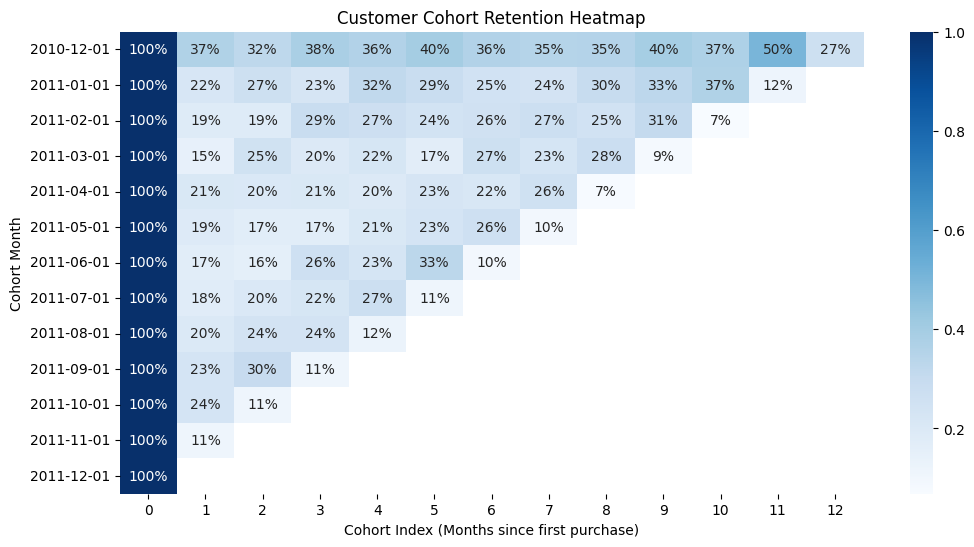

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    cohort_pd,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Cohort Index (Months since first purchase)")
plt.ylabel("Cohort Month")
plt.show()

###